<h1>Ecom Quant Lab — E-commerce Decision Intelligence</h1>
<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🔍 Competitor Scanner — Konkurrentanalyse og Prisposisjonering</h2>
<p>Quantitative Training Lab — Februar 2026</p>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🎯 Learning Objectives</h2>
<ul>
  <li>Forstå <b>hvorfor konkurrentdata er kritisk</b> for dropshipping-beslutninger</li>
  <li>Forklare <b>web scraping med requests + BeautifulSoup</b> — steg for steg</li>
  <li>Forstå <b>rotating user-agents og retry-logikk</b> — robust mot blokkering</li>
  <li>Implementere <b>append-only CSV</b> for historisk prissporing</li>
  <li>Beregne <b>prisposisjonering</b> og hva konkurrentpris gjør med vår margin</li>
  <li>Visualisere <b>prislandskap, historikk og margin-sensitivitet</b></li>
</ul>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🗺️ Oversikt</h2>
<ul>
  <li><b>Del 1 — Competitor Intelligence:</b> Hvorfor du trenger dette før du setter pris</li>
  <li><b>Del 2 — Web Scraping:</b> Hvordan requests + BeautifulSoup fungerer</li>
  <li><b>Del 3 — Anti-blocking:</b> Rotating user-agents, retry-logikk og graceful failure</li>
  <li><b>Del 4 — Append-only CSV:</b> Historisk data er verdifull — slett aldri</li>
  <li><b>Del 5 — Prisposisjonering:</b> Hva konkurrentpris betyr for vår margin</li>
  <li><b>Del 6 — Margin-sensitivitet:</b> Hva skjer med margin hvis vi justerer prisen?</li>
  <li><b>Implementering:</b> CompetitorScanner live med visualiseringer</li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 1 — Competitor Intelligence</h2>
<p>Pris er en av de viktigste variablene i dropshipping — men du kan ikke sette riktig pris uten å vite hva konkurrentene krever.</p>
<p><b>Hva skjer uten konkurrentdata:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Scenario A — Du priser for høyt:
  Din pris:        499 kr
  Konkurrent:      349 kr
  → Kunden kjøper hos konkurrenten
  → Du bruker annonsepenger for 0 salg

Scenario B — Du priser for lavt:
  Din pris:        299 kr
  Konkurrent:      499 kr
  → Du selger masse — men etterlater 200 kr per salg på bordet
  → Du underpriser produktet unødvendig
</pre>
<p><b>Med konkurrentdata kan du:</b></p>
<ul>
  <li>Prise <b>kompetitivt</b> — ikke for høyt, ikke unødvendig lavt</li>
  <li>Identifisere <b>prisrom</b> — er markedet villig til å betale mer?</li>
  <li>Spore <b>prisendringer</b> over tid — oppdager konkurrenter som dumper priser</li>
  <li>Beregne <b>margin ved ulike prispunkter</b> — hva koster det å matche markedet?</li>
</ul>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Tommelfingerregel:</b> Scan konkurrenter ukentlig. Prislandskapet endrer seg raskt i konkurranseutsatte dropshipping-nisjer.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 2 — Web Scraping med requests + BeautifulSoup</h2>
<p>Web scraping er automatisert innhenting av data fra nettsider.</p>
<p><b>Steg-for-steg slik det fungerer:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
1. requests.get(url)         → Hent HTML-siden (samme som nettleseren din)
2. BeautifulSoup(html, ...)  → Parse HTML til et søkbart tre
3. soup.find_all('article')  → Finn alle produktkort
4. article.find('span', class_='price') → Hent priselement
5. price.get_text()          → Ekstraher tekst: '349 kr'
6. parse_price_nok('349 kr') → Konverter til float: 349.0
</pre>
<p><b>Hvorfor requests + BS4 og ikke Selenium?</b></p>
<ul>
  <li><b>Hastighet:</b> requests er 10-100x raskere enn Selenium</li>
  <li><b>Enkelt:</b> Ingen nettleser-driver å installere og vedlikeholde</li>
  <li><b>Portabelt:</b> Kjører på alle servere uten display</li>
  <li><b>Begrensning:</b> Fungerer ikke for JavaScript-tunge sider (SPA)</li>
</ul>
<p style="background:rgba(255,215,0,0.1); padding:10px; border-left:4px solid rgba(255,215,0,0.7); border-radius:3px">
  ⚠️ <b>Viktig:</b> Finn.no og Google Shopping er JavaScript-tunge sider. I produksjon vil scraping av disse kreve Selenium eller en headless browser. CompetitorScanner er bygget for å håndtere dette gracefully — den returnerer tomme lister i stedet for å krasje.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 3 — Anti-Blocking: User-Agents og Retry-Logikk</h2>
<p>Nettsteder blokkerer bots. En profesjonell scraper omgår dette med to teknikker:</p>
<p><b>1. Rotating User-Agents</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
En User-Agent er en tekststreng som forteller serveren hvilken nettleser
du bruker. Bots bruker ofte en standard User-Agent som avslører dem.

Vi roterer mellom 6 realistiske nettleser-User-Agents:
  Chrome Windows   → ser ut som vanlig bruker
  Chrome Mac       → annen plattform
  Firefox Windows  → annen nettleser
  Safari Mac       → Apple bruker
  Chrome Linux     → Linux bruker
  Edge Windows     → Microsoft bruker

random.choice(USER_AGENTS) → tilfeldig valg for hvert request
</pre>
<p><b>2. Retry-Logikk med eksponentiell backoff</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
FOR forsøk = 1 til 3:
    PRØV  → requests.get(url)
    HVIS  → HTTP 403 eller 429:  returner None (blokkert)
    HVIS  → Nettverksfeil:       vent 2s, prøv igjen
    HVIS  → HTTP 200:            returner BeautifulSoup
ETTER 3 mislykkede forsøk → returner None
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>HTTP-statuskoder å kjenne til:</b><br>
  200 OK — Alt bra<br>
  403 Forbidden — Du er blokkert<br>
  429 Too Many Requests — Du sender for mange forespørsler<br>
  503 Service Unavailable — Serveren er midlertidig nede
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 4 — Graceful Failure og Robusthet</h2>
<p>En god scraper krasjer aldri — den håndterer feil og fortsetter.</p>
<p><b>Tre nivåer av feil vi håndterer:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Nivå 1 — Nettverksfeil (requests.RequestException):
  Årsak:    DNS-feil, timeout, internett nede
  Handling: Prøv igjen opptil 3 ganger med 2s pause
  Fallback: Returner None etter 3 feil

Nivå 2 — Blokkering (HTTP 403 / 429):
  Årsak:    Nettstedet gjenkjente oss som bot
  Handling: Returner None umiddelbart (ingen retries)
  Fallback: Andre scraping-kilder brukes fortsatt

Nivå 3 — HTML-parsing (manglende elementer):
  Årsak:    Nettstedet endret HTML-struktur
  Handling: try/except per artikkel, hopp over feil
  Fallback: Henter det den kan, ignorerer resten
</pre>
<p><b>Design-prinsipp:</b> én blokkert kilde stopper ikke hele systemet</p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
scan() kjører:
  → _scrape_finn()           (kan returnere [])
  → time.sleep(1)            (høflig mot serverne)
  → _scrape_google_shopping() (kan returnere [])
  → _append_to_csv(alle resultater fra begge)

Selv om begge kildene feiler → scan() returnerer []
→ Ingen krasj, ingen feilmelding til brukeren, bare tom liste
</pre>
<p style="background:rgba(255,99,71,0.1); padding:10px; border-left:4px solid rgba(255,99,71,0.5); border-radius:3px">
  ⚠️ <b>Etikk og juridikk:</b> Respekter robots.txt og Terms of Service. CompetitorScanner er et læringsverktøy. For produksjon, bruk offisielle API-er der de finnes (f.eks. Google Shopping API).
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 5 — Append-Only CSV for Historisk Prisdata</h2>
<p>Vi lagrer <b>aldri</b> over eksisterende data. Historikk er verdifull.</p>
<p><b>Hvorfor append-only?</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Uke 1:  Konkurrent A selger for 399 kr
Uke 2:  Konkurrent A selger for 349 kr  (prisdumping!)
Uke 3:  Konkurrent A selger for 299 kr  (krisesalg?)

Med append-only CSV kan du:
  → Se at konkurrenten dumpet prisene 2 uker i strekk
  → Analysere om dette er sesongbasert eller permanent
  → Ta informert beslutning om du skal matche prisen

Med overskriving ville du bare se: 299 kr
→ Ingen kontekst, ingen trendanalyse
</pre>
<p><b>CSV-kolonner og hva de betyr:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
timestamp        → Når ble prisen observert?
keyword          → Hvilket søkeord ble brukt?
seller           → Hvem selger produktet?
price_nok        → Hva er prisen? (NOK)
url              → Hvor kan jeg se produktet?
our_price        → Vår pris på scannetidspunktet
our_margin       → Vår margin (%) på scannetidspunktet
price_difference → our_price - price_nok (+: vi er dyrere)
we_are_cheaper   → True/False: er vi billigst?
</pre>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 6 — Prisposisjonering og Margin-Sensitivitet</h2>
<p>Konkurrentdata er nyttig — men det er <b>konsekvensene for marginen</b> som faktisk betyr noe.</p>
<p><b>To nøkkelspørsmål:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Spørsmål 1: Hva er vår posisjon i markedet?
  → Er vi billigst, gjennomsnitt eller dyreste?
  → Hvor mange konkurrenter er billigere enn oss?

Spørsmål 2: Hva koster det å matche konkurrentene?
  → Hvis konkurrenten selger for 299 kr og vi for 349 kr:
  → Hva blir vår margin hvis vi matcher 299 kr?
  → Er det fortsatt lønnsomt? Har vi råd til annonser?
</pre>
<p><b>Margin-formel ved konkurrentpris:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Våre kostnader = our_price × (1 - our_margin)
               = 349 × (1 - 0.684) = 110.3 kr

Margin ved konkurransepris = (konkurrent_pris - kostnader) / konkurrent_pris
  → Konkurrent 299 kr: (299 - 110.3) / 299 = 63.1%  ← fortsatt OK
  → Konkurrent 200 kr: (200 - 110.3) / 200 = 44.9%  ← trangere
  → Konkurrent 130 kr: (130 - 110.3) / 130 = 15.2%  ← vanskelig å skalere
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Strategisk innsikt:</b> Du trenger ikke alltid å matche laveste pris. Noen ganger er det bedre å differensiere på kvalitet, leveringstid eller merkevare — og beholde den høyere marginen.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 1: Imports og Setup</h2>
<p>Vi setter opp CompetitorScanner og genererer realistisk mock-data for visualiseringene (siden scraping av live nettsteder er usikkert i notebook-miljø).</p>

In [1]:
import sys
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.append('../src')
from competitor_scanner import CompetitorScanner, CSV_PATH, CSV_COLUMNS

print('Imports OK')
print(f'CSV vil lagres til: {CSV_PATH}')

Imports OK
CSV vil lagres til: data/competitor_data.csv


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 2: Juicer-Scanner med Mock-Data</h2>
<p>Vi initialiserer scanneren med juicer-produktets parametre og genererer realistiske konkurrentdata for demonstrasjon.</p>

In [2]:
# Opprett scanner for juicer-produktet
scanner = CompetitorScanner(
    keyword    = 'juicer bærbar',
    our_price  = 349,
    our_margin = 0.684,
)

print('Scanner initialisert')
print(f'Produkt:  juicer bærbar')
print(f'Vår pris: {scanner.our_price} NOK')
print(f'Margin:   {scanner.our_margin*100:.1f}%')
print(f'Kostnader (beregnet): {scanner.our_price * (1 - scanner.our_margin):.1f} NOK')

Scanner initialisert
Produkt:  juicer bærbar
Vår pris: 349 NOK
Margin:   68.4%
Kostnader (beregnet): 110.3 NOK


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 3: Generer Historisk Mock-Data</h2>
<p>Vi simulerer 4 uker med prisdata fra 8 konkurrenter for å demonstrere historisk prisanalyse og visualiseringer.</p>

In [3]:
import random
random.seed(42)

# Mock konkurrenter med realistiske prisnivåer
konkurrenter = [
    ('Nettbutikk AS',      320),
    ('Gadget Guru',        299),
    ('NordicHome',         379),
    ('TechDeal NO',        349),
    ('SmartShop Norge',    419),
    ('ElektroExpress',     289),
    ('Hverdagsprodukter',  359),
    ('ImportDirekte',      310),
]

# Generer 4 ukers historikk (ukentlige scan)
base_date = datetime(2026, 1, 26)  # 4 uker tilbake
mock_rows = []

for uke in range(4):
    ts = (base_date + timedelta(weeks=uke)).isoformat(timespec='seconds')
    for selger, base_price in konkurrenter:
        # Legg til litt variasjon uke til uke (+/-10%)
        price = round(base_price * random.uniform(0.92, 1.08))
        row = {
            'timestamp':        ts,
            'keyword':          scanner.keyword,
            'seller':           selger,
            'price_nok':        price,
            'url':              f'https://example.com/{selger.lower().replace(" ", "-")}',
            'our_price':        scanner.our_price,
            'our_margin':       round(scanner.our_margin * 100, 1),
            'price_difference': round(scanner.our_price - price, 2),
            'we_are_cheaper':   scanner.our_price < price,
        }
        mock_rows.append(row)

# Skriv til CSV via scanner sin interne metode
scanner._append_to_csv(mock_rows)

print(f'Genererte {len(mock_rows)} historiske rader ({4} uker × {len(konkurrenter)} selgere)')

# Hent summary basert på siste scan (siste uke)
summary = scanner.get_summary()
print()
print('=== SUMMARY — SISTE SCAN ===')
for k, v in summary.items():
    print(f'  {k:30} {v}')

Genererte 32 historiske rader (4 uker × 8 selgere)

=== SUMMARY — SISTE SCAN ===
  keyword                        juicer bærbar
  our_price                      349
  competitor_count               8
  min_price                      291.0
  max_price                      442.0
  avg_price                      343.5
  cheaper_than_us                5
  more_expensive_than_us         3
  we_are_cheapest                False
  margin_at_avg_price            67.9


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering 1 — Prislandskap: Konkurrenter vs. Vår Pris</h2>

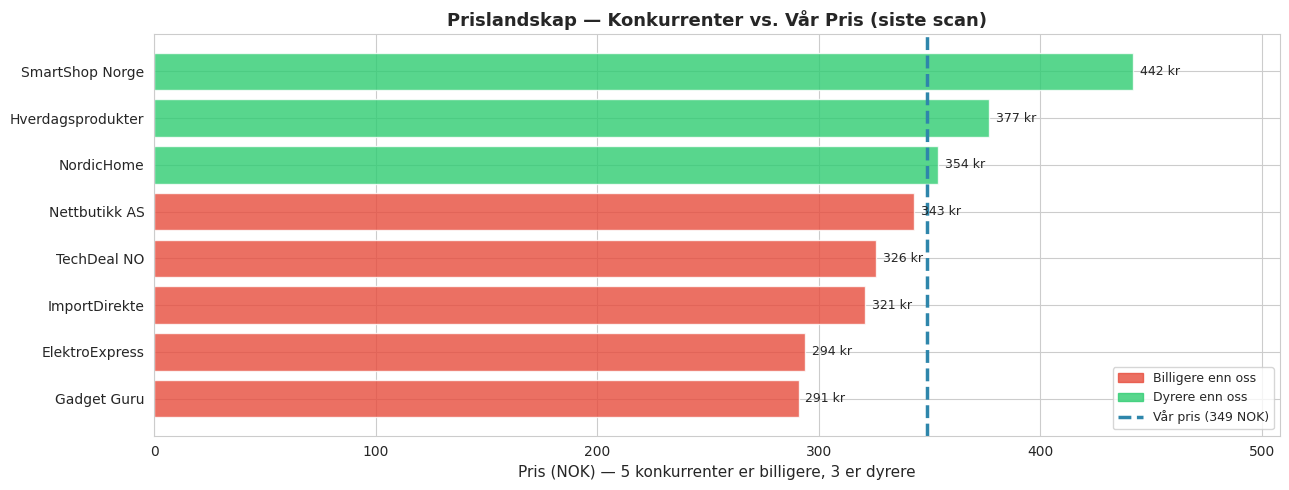

Billigste konkurrent: 291 NOK (Gadget Guru)
Dyreste konkurrent:   442 NOK (SmartShop Norge)
Snittkonkurrent:      344 NOK


In [4]:
# Hent siste scan-runde fra mock-data
last_ts = max(r['timestamp'] for r in mock_rows)
latest  = [r for r in mock_rows if r['timestamp'] == last_ts]
latest.sort(key=lambda r: r['price_nok'])

sellers = [r['seller'] for r in latest]
prices  = [r['price_nok'] for r in latest]
colors  = ['#e74c3c' if p < scanner.our_price else '#2ecc71' for p in prices]

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.barh(sellers, prices, color=colors, alpha=0.8, edgecolor='white')

# Markér vår pris
ax.axvline(scanner.our_price, color='#2E86AB', linewidth=2.5, linestyle='--',
           label=f'Vår pris ({scanner.our_price} NOK)')

# Prisetiketter på stengene
for bar, price in zip(bars, prices):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{price} kr', va='center', fontsize=9)

# Legende-proxy
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#e74c3c', alpha=0.8, label='Billigere enn oss'),
    Patch(color='#2ecc71', alpha=0.8, label='Dyrere enn oss'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color='#2E86AB',
          linewidth=2.5, linestyle='--', label=f'Vår pris ({scanner.our_price} NOK)')],
          fontsize=9)

ax.set_xlabel('Pris (NOK)', fontsize=12)
ax.set_title('Prislandskap — Konkurrenter vs. Vår Pris (siste scan)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(prices) * 1.15)

# Annoteringer
cheaper_count = sum(1 for p in prices if p < scanner.our_price)
pricier_count = len(prices) - cheaper_count
ax.set_xlabel(
    f'Pris (NOK) — {cheaper_count} konkurrenter er billigere, {pricier_count} er dyrere',
    fontsize=11
)

plt.tight_layout()
plt.show()

print(f'Billigste konkurrent: {min(prices)} NOK ({sellers[0]})')
print(f'Dyreste konkurrent:   {max(prices)} NOK ({sellers[-1]})')
print(f'Snittkonkurrent:      {sum(prices)/len(prices):.0f} NOK')

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering 2 — Prishistorikk over Tid</h2>

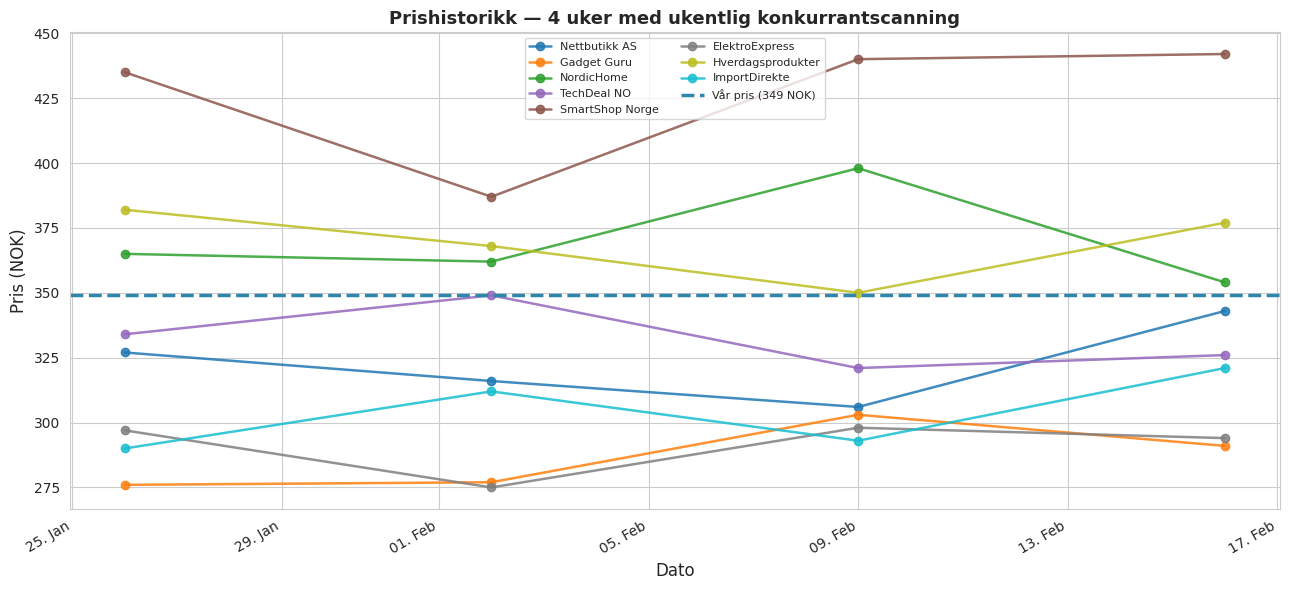

In [5]:
# Grupper data per selger per uke
from collections import defaultdict

selger_historikk = defaultdict(lambda: {'ts': [], 'prices': []})
for row in mock_rows:
    selger_historikk[row['seller']]['ts'].append(row['timestamp'])
    selger_historikk[row['seller']]['prices'].append(row['price_nok'])

fig, ax = plt.subplots(figsize=(13, 6))

colors_map = plt.cm.tab10(np.linspace(0, 1, len(selger_historikk)))

for (selger, data), color in zip(selger_historikk.items(), colors_map):
    dates  = [datetime.fromisoformat(t) for t in data['ts']]
    prices = data['prices']
    ax.plot(dates, prices, marker='o', linewidth=1.8,
            color=color, label=selger, alpha=0.85)

# Vår pris som horisontal linje
ax.axhline(scanner.our_price, color='#2E86AB', linewidth=2.5,
           linestyle='--', label=f'Vår pris ({scanner.our_price} NOK)')

ax.set_xlabel('Dato', fontsize=12)
ax.set_ylabel('Pris (NOK)', fontsize=12)
ax.set_title('Prishistorikk — 4 uker med ukentlig konkurrantscanning',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d. %b'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering 3 — Margin-Sensitivitetsanalyse</h2>
<p>Hva skjer med vår margin om vi justerer prisen for å matche markedet?</p>

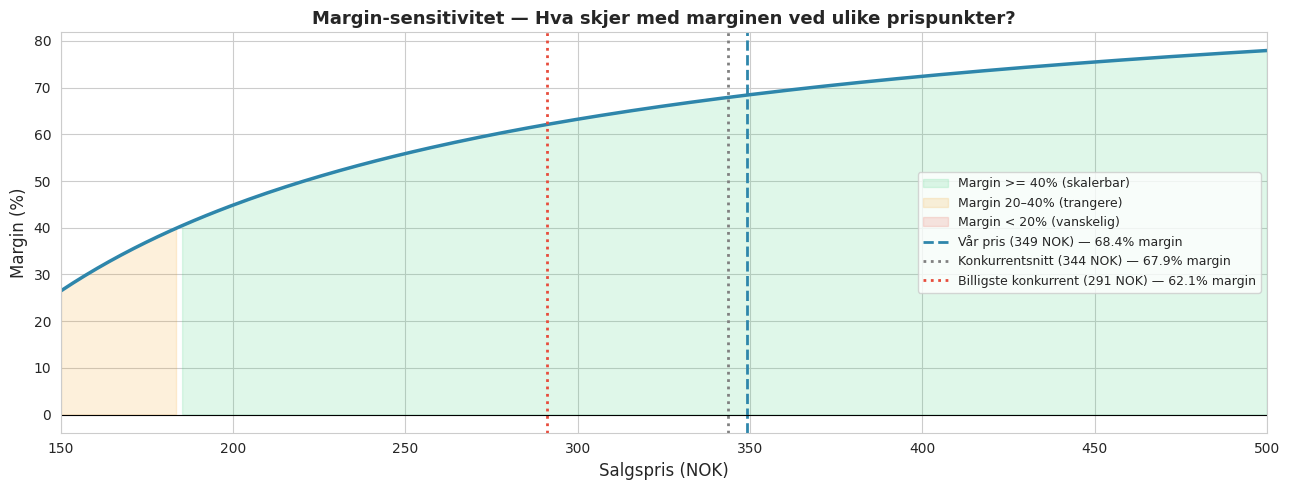

Våre kostnader (COGS + frakt + payment):  110.3 NOK
Vår pris:                                  349 NOK  (68.4% margin)
Konkurrentsnitt:                           344 NOK  (67.9% margin)
Billigste konkurrent:                      291 NOK  (62.1% margin)


In [6]:
# Beregn margin ved ulike prispunkter
our_costs = scanner.our_price * (1 - scanner.our_margin)

price_range = np.linspace(150, 500, 200)
margins     = [(p - our_costs) / p * 100 for p in price_range]

fig, ax = plt.subplots(figsize=(13, 5))

# Marginskurven
ax.plot(price_range, margins, color='#2E86AB', linewidth=2.5)

# Fyll marginsoner
ax.fill_between(price_range, margins, 0,
                where=[m >= 40 for m in margins],
                alpha=0.15, color='#2ecc71', label='Margin >= 40% (skalerbar)')
ax.fill_between(price_range, margins, 0,
                where=[20 <= m < 40 for m in margins],
                alpha=0.15, color='#f39c12', label='Margin 20–40% (trangere)')
ax.fill_between(price_range, margins, 0,
                where=[m < 20 for m in margins],
                alpha=0.15, color='#e74c3c', label='Margin < 20% (vanskelig)')

# Markér vår pris og konkurrentpriser
ax.axvline(scanner.our_price, color='#2E86AB', linewidth=2,
           linestyle='--', label=f'Vår pris ({scanner.our_price} NOK) — {scanner.our_margin*100:.1f}% margin')

konkurrent_snitt = sum(p['price_nok'] for p in latest) / len(latest)
margin_ved_snitt = (konkurrent_snitt - our_costs) / konkurrent_snitt * 100
ax.axvline(konkurrent_snitt, color='grey', linewidth=2, linestyle=':',
           label=f'Konkurrentsnitt ({konkurrent_snitt:.0f} NOK) — {margin_ved_snitt:.1f}% margin')

min_price = min(r['price_nok'] for r in latest)
margin_ved_min = (min_price - our_costs) / min_price * 100
ax.axvline(min_price, color='#e74c3c', linewidth=2, linestyle=':',
           label=f'Billigste konkurrent ({min_price} NOK) — {margin_ved_min:.1f}% margin')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Salgspris (NOK)', fontsize=12)
ax.set_ylabel('Margin (%)', fontsize=12)
ax.set_title('Margin-sensitivitet — Hva skjer med marginen ved ulike prispunkter?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(150, 500)

plt.tight_layout()
plt.show()

print(f'Våre kostnader (COGS + frakt + payment):  {our_costs:.1f} NOK')
print(f'Vår pris:                                  {scanner.our_price} NOK  ({scanner.our_margin*100:.1f}% margin)')
print(f'Konkurrentsnitt:                           {konkurrent_snitt:.0f} NOK  ({margin_ved_snitt:.1f}% margin)')
print(f'Billigste konkurrent:                      {min_price} NOK  ({margin_ved_min:.1f}% margin)')

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">✅ Key Takeaways</h2>
<ul>
  <li><b>Konkurrentdata er beslutningsgrunnlag</b> — ikke kuriosa. Sett pris basert på markedet.</li>
  <li><b>Graceful failure</b> er kjernen i robust scraping — krasj aldri, returner tom liste</li>
  <li><b>Rotating user-agents + retry</b> reduserer blokkering uten å krenke etikk</li>
  <li><b>Append-only CSV</b> gir historisk perspektiv — du ser trender, ikke bare øyeblikk</li>
  <li><b>Laveste pris er ikke alltid riktig</b> — sjekk hva det gjør med marginen din</li>
  <li><b>Margin-sensitivitetsanalysen</b> viser prispunktene der du fortsatt kan skalere</li>
  <li><b>Scanner + BreakEven + KPI + Simulator</b> gir komplett beslutningssystem</li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">❓ Refleksjonsspørsmål</h2>
<ol>
  <li>Hva er den viktigste grunnen til å bruke append-only CSV i stedet for å overskrive?</li>
  <li>Forklar hva HTTP 403 og 429 betyr, og hvorfor vi behandler dem ulikt fra nettverksfeil.</li>
  <li>En konkurrent selger for 289 kr. Vår pris er 349 kr og margin er 68.4%. Hva er vår margin om vi matcher 289 kr? (Kostnader = 349 × 0.316)</li>
  <li>Hvorfor roterer vi user-agents i stedet for å bruke én fast?</li>
  <li>Hva betyr det at <code>scan()</code> returnerer en tom liste — er det en feil eller forventet oppførsel?</li>
  <li>Når er det riktig å <b>ikke</b> matche den billigste konkurrenten?</li>
</ol>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🎯 Neste steg</h2>
<p>Ecom Quant Lab er nå komplett med fire moduler:</p>
<ul>
  <li>✅ <b>BreakEvenCalculator</b> — hva er max CPA, margin og organisk break-even?</li>
  <li>✅ <b>KPIDecisionEngine</b> — scale, hold eller kill basert på faktiske data?</li>
  <li>✅ <b>CampaignSimulator</b> — hva er sannsynlig å skje med dette budsjettet?</li>
  <li>✅ <b>CompetitorScanner</b> — hva selger konkurrentene og til hvilken pris?</li>
</ul>
<p>Mulige neste steg:</p>
<ul>
  <li>Koble inn <b>ekte kampanje-data</b> fra Meta Ads eller Google Ads CSV-eksport</li>
  <li>Bygg et <b>Streamlit-dashboard</b> som samler alle fire moduler i ett UI</li>
  <li>Legg til <b>Pricerunner API</b> for pålitelig prisdata uten scraping-problemer</li>
  <li>Implementer <b>automatisk ukentlig scan</b> med cron-jobb og e-postvarsler</li>
</ul>